In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
#import seaborn as sns

In [2]:
data = './data/DEMANDA_HM_2010_2020.xlsx'
df = pd.read_excel(data)
df.head()

,CVE_AREA,FECHA,H1,H2,H3,H4,H5,H6,H7,H8,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
0,4,01/01/10 00:00:00,1329111,1279150,1234408,1178964,1133478,1104206,1085051,1066775,...,1095139,1085790,1088422,1091967,1171458,1373346,1398079,1380752,1329063,1259260
1,4,02/01/10 00:00:00,1181295,1107378,1066142,1043005,1027027,1026406,1053201,1087382,...,1359275,1358094,1345975,1336211,1396994,1592685,1577978,1534910,1485144,1407471
2,4,03/01/10 00:00:00,1299207,1213701,1158945,1128029,1112696,1109900,1120089,1134807,...,1302110,1301595,1289896,1283963,1360209,1577182,1604558,1575134,1498439,1379300
3,4,04/01/10 00:00:00,1263890,1188647,1151757,1126310,1117816,1136196,1190691,1290986,...,1515727,1526309,1516187,1504997,1547759,1698651,1701012,1650807,1563854,1459627
4,4,05/01/10 00:00:00,1351070,1276229,1231296,1202631,1192587,1203801,1246099,1343796,...,1549784,1552610,1550593,1536242,1578431,1733800,1741204,1695270,1592695,1480902


In [3]:
df1 = df.loc[:, 'FECHA':'H24']
df1 = df1.set_index('FECHA')
df1

,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
FECHA,,,,,,,,,,,,,,,,,,,,,
01/01/10 00:00:00,1329111,1279150,1234408,1178964,1133478,1104206,1085051,1066775,1007690,1019949,...,1095139,1085790,1088422,1091967,1171458,1373346,1398079,1380752,1329063,1259260
02/01/10 00:00:00,1181295,1107378,1066142,1043005,1027027,1026406,1053201,1087382,1105590,1188363,...,1359275,1358094,1345975,1336211,1396994,1592685,1577978,1534910,1485144,1407471
03/01/10 00:00:00,1299207,1213701,1158945,1128029,1112696,1109900,1120089,1134807,1117230,1163229,...,1302110,1301595,1289896,1283963,1360209,1577182,1604558,1575134,1498439,1379300
04/01/10 00:00:00,1263890,1188647,1151757,1126310,1117816,1136196,1190691,1290986,1336533,1381116,...,1515727,1526309,1516187,1504997,1547759,1698651,1701012,1650807,1563854,1459627
05/01/10 00:00:00,1351070,1276229,1231296,1202631,1192587,1203801,1246099,1343796,1382356,1416746,...,1549784,1552610,1550593,1536242,1578431,1733800,1741204,1695270,1592695,1480902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14/11/20 00:00:00,2325994,2247689,2183638,2123104,2080831,2068163,2073294,2078741,2140763,2252419,...,2455125,2427870,2405933,2389551,2454104,2510051,2468291,2424337,2365971,2303397
15/11/20 00:00:00,2224374,2148334,2091963,2043327,2004156,1999663,1990733,1971618,1992885,2080658,...,2305505,2324398,2346889,2324986,2354214,2422371,2415803,2403727,2359287,2298818
16/11/20 00:00:00,2231220,2154199,2093139,2030629,1983106,1992437,1995074,1991516,2027237,2143462,...,2487423,2542046,2575277,2547411,2560014,2635693,2619136,2602121,2559615,2472636


In [4]:
df_hillo = pd.concat([df1.stack()], axis=1)
df_hillo.columns = ['consumo']
df_hillo = df_hillo.reset_index().rename(columns={'level_1': 'hora'})

In [5]:
df_hillo.head(12)

,FECHA,hora,consumo
0,01/01/10 00:00:00,H1,1329111
1,01/01/10 00:00:00,H2,1279150
2,01/01/10 00:00:00,H3,1234408
3,01/01/10 00:00:00,H4,1178964
4,01/01/10 00:00:00,H5,1133478
5,01/01/10 00:00:00,H6,1104206
6,01/01/10 00:00:00,H7,1085051
7,01/01/10 00:00:00,H8,1066775
8,01/01/10 00:00:00,H9,1007690
9,01/01/10 00:00:00,H10,1019949


In [6]:
df_hillo['FECHA'] =  [x[:8] for x in df_hillo['FECHA']]

In [7]:
df_hillo['horario'] =  df2['hora']

NameError: name 'df2' is not defined

In [8]:
df_hillo

,FECHA,hora,consumo
0,01/01/10,H1,1329111
1,01/01/10,H2,1279150
2,01/01/10,H3,1234408
3,01/01/10,H4,1178964
4,01/01/10,H5,1133478
...,...,...,...
95395,18/11/20,H20,0
95396,18/11/20,H21,0
95397,18/11/20,H22,0
95398,18/11/20,H23,0


In [9]:
hora_group = list(df_hillo.hora.unique())
hora_group
horas = ['01:00:00', '02:00:00', '03:00:00', '04:00:00', '05:00:00', '06:00:00', 
         '07:00:00', '08:00:00', '09:00:00', '10:00:00', '11:00:00', '12:00:00',
         '13:00:00', '14:00:00', '15:00:00', '16:00:00', '17:00:00', '18:00:00', 
         '19:00:00', '20:00:00', '21:00:00', '22:00:00', '23:00:00', '00:00:00']

df_hillo['hora'].replace(hora_group, horas, inplace=True)

In [10]:

df_hillo['fecha hora'] = df_hillo['FECHA'].map(str)+' '+df_hillo['hora'].map(str)
df_hillo['fecha hora'] = pd.to_datetime(df_hillo['fecha hora'])
df_hillo['FECHA'] = pd.to_datetime(df_hillo['FECHA'])
df_hillo['dia_semana'] = df_hillo['FECHA'].dt.day_name()
df_hillo

,FECHA,hora,consumo,fecha hora,dia_semana
0,2010-01-01,01:00:00,1329111,2010-01-01 01:00:00,Friday
1,2010-01-01,02:00:00,1279150,2010-01-01 02:00:00,Friday
2,2010-01-01,03:00:00,1234408,2010-01-01 03:00:00,Friday
3,2010-01-01,04:00:00,1178964,2010-01-01 04:00:00,Friday
4,2010-01-01,05:00:00,1133478,2010-01-01 05:00:00,Friday
...,...,...,...,...,...
95395,2020-11-18,20:00:00,0,2020-11-18 20:00:00,Wednesday
95396,2020-11-18,21:00:00,0,2020-11-18 21:00:00,Wednesday
95397,2020-11-18,22:00:00,0,2020-11-18 22:00:00,Wednesday
95398,2020-11-18,23:00:00,0,2020-11-18 23:00:00,Wednesday


<AxesSubplot:title={'center':'consumo'}, xlabel='dia_semana'>

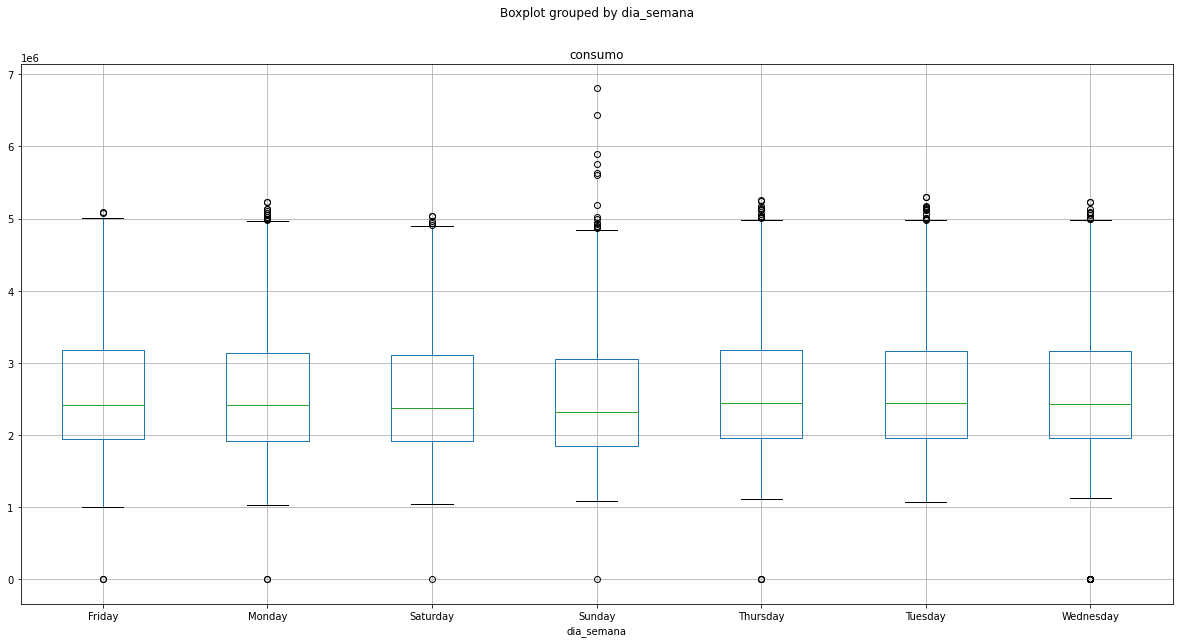

In [11]:
df_hillo.boxplot(by='dia_semana', column=['consumo'], figsize=(20,10))

<AxesSubplot:title={'center':'consumo'}, xlabel='hora'>

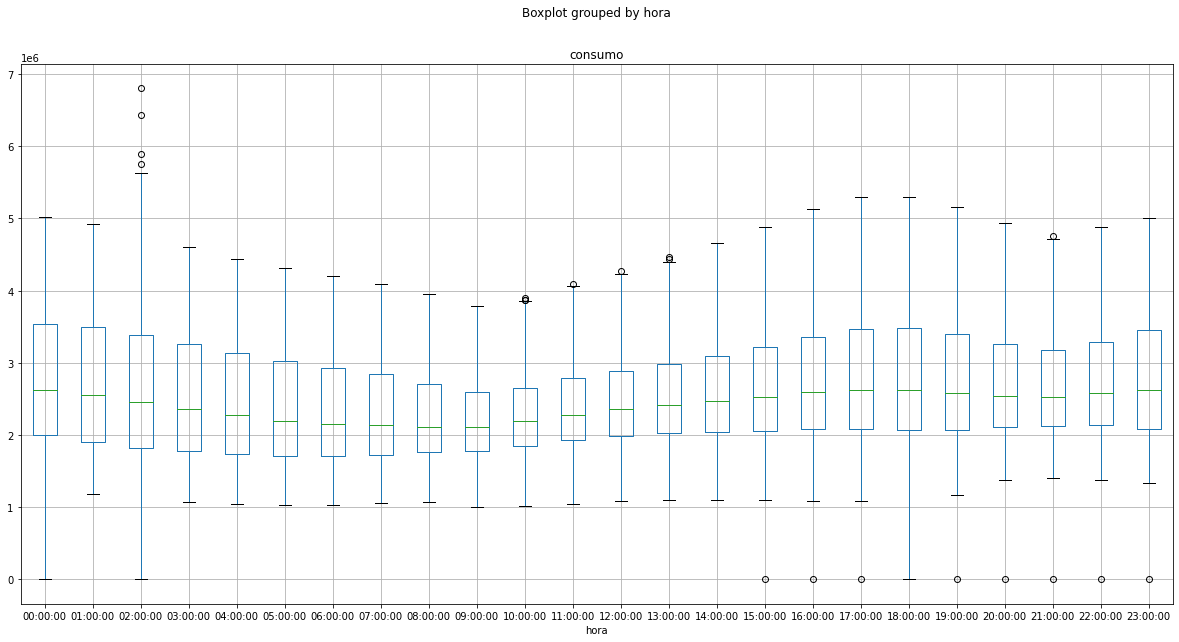

In [12]:
df_hillo.boxplot(by='hora', column=['consumo'], figsize=(20,10))

In [13]:
count_nan = len(df) - df.count()
print(count_nan)  

CVE_AREA    0
FECHA       0
H1          0
H2          0
H3          0
H4          0
H5          0
H6          0
H7          0
H8          0
H9          0
H10         0
H11         0
H12         0
H13         0
H14         0
H15         0
H16         0
H17         0
H18         0
H19         0
H20         0
H21         0
H22         0
H23         0
H24         0
dtype: int64


In [14]:
data = './data/DEMANDA_ZC_2016_2020.xlsx'
dfZona = pd.read_excel(data)
dfZona.head()

,ZC_DATE,ZC_ZONA,H1,H2,H3,H4,H5,H6,H7,H8,...,H17,H18,H19,H20,H21,H22,H23,H24,ZC_MODELO,ZC_ORDEN
0,01/01/16 00:00:00,CAB,68.994,70.697,76.095,75.123,74.895,74.740,74.560,73.306,...,68.315,71.063,78.548,80.241,82.004,81.074,78.466,75.052,M2,1
1,01/01/16 00:00:00,NOG,127.452,126.151,125.458,122.960,121.688,120.804,120.886,116.718,...,107.718,115.501,133.168,136.517,136.518,134.781,129.639,123.164,M2,2
2,01/01/16 00:00:00,HMO,235.183,230.731,224.459,219.945,216.546,216.365,215.302,205.709,...,206.079,216.307,240.721,243.611,241.766,237.769,231.390,225.622,M2,3
3,01/01/16 00:00:00,GYM,42.719,41.736,40.559,40.281,39.176,38.730,39.547,37.644,...,40.543,41.186,46.645,47.282,46.778,45.306,43.122,40.830,M2,4
4,01/01/16 00:00:00,OBR,90.014,87.246,84.130,81.361,79.023,78.192,77.692,74.575,...,82.764,87.074,96.465,98.729,98.322,95.362,91.268,86.419,M2,5


In [15]:
dfZona.shape

(19502, 28)

In [16]:
dfZona.describe()

,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,ZC_ORDEN
count,19502.000000,19502.000000,19502.000000,19502.000000,19502.000000,19502.000000,19502.000000,19501.000000,19501.000000,19502.000000,...,19488.000000,19490.000000,19490.000000,19490.000000,19490.000000,19490.000000,19490.000000,19490.000000,19490.000000,19502.000000
mean,455.403525,437.561835,422.208697,408.791947,399.447932,390.031701,383.069206,394.822505,415.134544,432.772496,...,513.370669,505.082338,489.676473,484.660899,496.119835,508.356381,508.225915,495.991177,476.171696,9.219619
std,801.203707,771.809185,745.358033,720.531679,702.887949,681.189017,662.211734,680.075073,712.997547,740.446386,...,889.392269,875.768044,845.876735,827.982191,845.430443,871.858878,877.161883,861.931394,833.577009,12.493088
min,15.539000,7.404000,0.995000,0.425000,0.427000,4.291000,18.361000,21.032000,25.814000,32.316000,...,29.222000,31.422000,32.265000,41.953000,47.282000,46.778000,0.000000,0.000000,0.000000,1.000000
25%,124.198250,119.336000,115.519750,112.753750,111.471250,111.711750,111.718000,115.526000,121.049000,125.812000,...,144.078500,141.933000,138.825750,141.952250,146.806750,147.718500,144.495500,138.351000,130.749000,3.000000
50%,185.469500,178.035000,171.798000,166.545500,162.706500,159.513000,158.442000,164.801000,173.284000,180.634000,...,207.552000,203.146500,196.492500,197.963500,203.321500,207.845500,207.884500,202.505000,194.046000,6.000000
75%,331.988500,317.933500,305.308500,294.436000,284.766000,276.613000,268.882750,273.716000,287.912000,302.177000,...,364.278000,356.632500,343.127500,343.651750,354.317000,364.846750,368.700250,362.344250,348.102500,9.000000
max,4606.518000,4441.294000,4314.021000,4190.345000,4073.341000,3952.909000,3793.902000,3889.392000,4086.315000,4268.351000,...,5242.133000,5134.812000,4932.677000,4718.475000,4866.766000,5015.604000,5024.092000,4924.571000,4779.514000,50.000000


In [17]:
dfZona = dfZona.loc[:, 'ZC_DATE':'H24']

In [18]:
dfZona['ZC_DATE'] =  [x[:8] for x in dfZona['ZC_DATE']]
dfZona['fecha zona'] = dfZona['ZC_DATE'].map(str)+' - '+dfZona['ZC_ZONA'].map(str)
dfZona

,ZC_DATE,ZC_ZONA,H1,H2,H3,H4,H5,H6,H7,H8,...,H16,H17,H18,H19,H20,H21,H22,H23,H24,fecha zona
0,01/01/16,CAB,68.994,70.697,76.095,75.123,74.895,74.740,74.560,73.306,...,68.220,68.315,71.063,78.548,80.241,82.004,81.074,78.466,75.052,01/01/16 - CAB
1,01/01/16,NOG,127.452,126.151,125.458,122.960,121.688,120.804,120.886,116.718,...,108.640,107.718,115.501,133.168,136.517,136.518,134.781,129.639,123.164,01/01/16 - NOG
2,01/01/16,HMO,235.183,230.731,224.459,219.945,216.546,216.365,215.302,205.709,...,208.046,206.079,216.307,240.721,243.611,241.766,237.769,231.390,225.622,01/01/16 - HMO
3,01/01/16,GYM,42.719,41.736,40.559,40.281,39.176,38.730,39.547,37.644,...,40.604,40.543,41.186,46.645,47.282,46.778,45.306,43.122,40.830,01/01/16 - GYM
4,01/01/16,OBR,90.014,87.246,84.130,81.361,79.023,78.192,77.692,74.575,...,82.046,82.764,87.074,96.465,98.729,98.322,95.362,91.268,86.419,01/01/16 - OBR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,18/11/20,GSV,115.412,108.904,103.618,99.590,96.752,96.358,96.799,98.656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18/11/20 - GSV
19498,18/11/20,CUL,423.606,400.309,378.418,359.549,345.160,333.565,322.163,330.619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18/11/20 - CUL
19499,18/11/20,MZT,226.689,216.535,207.710,200.770,196.068,193.143,186.704,192.077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18/11/20 - MZT
19500,18/11/20,GCRNO,2363.512,2252.410,2175.909,2122.025,2101.986,2106.221,2105.899,2175.824,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18/11/20 - GCRNO


In [19]:
dfZona = dfZona.loc[:, 'H1':'fecha zona']
dfZona = dfZona.set_index('fecha zona')
dfZona

,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
fecha zona,,,,,,,,,,,,,,,,,,,,,
01/01/16 - CAB,68.994,70.697,76.095,75.123,74.895,74.740,74.560,73.306,72.409,74.451,...,68.893,68.220,68.315,71.063,78.548,80.241,82.004,81.074,78.466,75.052
01/01/16 - NOG,127.452,126.151,125.458,122.960,121.688,120.804,120.886,116.718,115.846,117.166,...,108.130,108.640,107.718,115.501,133.168,136.517,136.518,134.781,129.639,123.164
01/01/16 - HMO,235.183,230.731,224.459,219.945,216.546,216.365,215.302,205.709,202.548,206.944,...,209.572,208.046,206.079,216.307,240.721,243.611,241.766,237.769,231.390,225.622
01/01/16 - GYM,42.719,41.736,40.559,40.281,39.176,38.730,39.547,37.644,38.364,38.941,...,41.380,40.604,40.543,41.186,46.645,47.282,46.778,45.306,43.122,40.830
01/01/16 - OBR,90.014,87.246,84.130,81.361,79.023,78.192,77.692,74.575,75.546,78.592,...,82.230,82.046,82.764,87.074,96.465,98.729,98.322,95.362,91.268,86.419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18/11/20 - GSV,115.412,108.904,103.618,99.590,96.752,96.358,96.799,98.656,105.078,110.694,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18/11/20 - CUL,423.606,400.309,378.418,359.549,345.160,333.565,322.163,330.619,362.882,395.012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18/11/20 - MZT,226.689,216.535,207.710,200.770,196.068,193.143,186.704,192.077,207.907,224.384,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
dfZona = pd.concat([dfZona.stack()], axis=1)
dfZona.columns = ['consumo']
dfZona = dfZona.reset_index().rename(columns={'level_1': 'hora'})
dfZona.head(35)

,fecha zona,hora,consumo
0,01/01/16 - CAB,H1,68.994
1,01/01/16 - CAB,H2,70.697
2,01/01/16 - CAB,H3,76.095
3,01/01/16 - CAB,H4,75.123
4,01/01/16 - CAB,H5,74.895
5,01/01/16 - CAB,H6,74.740
6,01/01/16 - CAB,H7,74.560
7,01/01/16 - CAB,H8,73.306
8,01/01/16 - CAB,H9,72.409
9,01/01/16 - CAB,H10,74.451


In [21]:
dfZona['fecha'] =  [x[:8] for x in dfZona['fecha zona']]

In [22]:
dfZona['zona'] =  [x[11:16] for x in dfZona['fecha zona']]

In [23]:
dfZona

,fecha zona,hora,consumo,fecha,zona
0,01/01/16 - CAB,H1,68.994,01/01/16,CAB
1,01/01/16 - CAB,H2,70.697,01/01/16,CAB
2,01/01/16 - CAB,H3,76.095,01/01/16,CAB
3,01/01/16 - CAB,H4,75.123,01/01/16,CAB
4,01/01/16 - CAB,H5,74.895,01/01/16,CAB
...,...,...,...,...,...
467917,18/11/20 - DBRT,H10,2565.097,18/11/20,DBRT
467918,18/11/20 - DBRT,H11,2655.209,18/11/20,DBRT
467919,18/11/20 - DBRT,H12,2739.605,18/11/20,DBRT
467920,18/11/20 - DBRT,H13,2801.753,18/11/20,DBRT


In [24]:
dfZona.dtypes

fecha zona     object
hora           object
consumo       float64
fecha          object
zona           object
dtype: object

In [25]:
count_nan = len(dfZona) - dfZona.count()
print(count_nan) 

fecha zona    0
hora          0
consumo       0
fecha         0
zona          0
dtype: int64


In [26]:
sns.set(rc={'figure.figsize':(20,10)})
sns.scatterplot(x='ZC_ZONA', y='H12', data= dfZona)

NameError: name 'sns' is not defined

In [ ]:
dfZona.boxplot(by='ZC_ZONA', column=['H12'], figsize=(20,10))